### **Real Estate AI Platform**
### Transforming Property Insights & Decision-Making:

The platform is designed to provide a comprehensive and intelligent solution for the real estate market, integrating advanced data analytics, machine learning, and deep learning techniques. Its core objective is to accurately predict house prices using a wide array of features such as the number of bedrooms, bathrooms, house size, and other relevant attributes. Beyond price prediction, the platform aims to offer detailed insights into property valuation, market trends, and feature importance, empowering users to make informed decisions. It leverages a Retrieval-Augmented Generation (RAG) system to answer natural language queries about properties, backed by image descriptions generated through a BLIP-2 model for visual context and estimate property price related to uploaded images. The integrated Gradio interface allows for interactive price prediction with SHAP explanations, making the model's decisions transparent and understandable.

# **Data Collection**

**House Prices Dataset**

https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset

The dataset has 1 CSV file with 12 columns

Content:

1.brokered by (categorically encoded agency/broker)

2.status (Housing status - a. ready for sale or b. ready to build)

3.price (Housing price, it is either the current listing price or recently sold
price if the house is sold recently)

4.bed (# of beds)

5.bath (# of bathrooms)

6.acre_lot (Property / Land size in **acres**)

7.street (categorically encoded street address)

8.city (city name)

9.state (state name)

10.zip_code (postal code of the area)

11.house_size (house area/size/living space in **square feet**)

12.prev_sold_date (Previously sold date)


# **Import necessary libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.listdir('/content/drive/MyDrive')

['socal2.csv',
 'realtor-data.csv',
 'Saved from the Google app',
 'Colab Notebooks',
 'Vertrag - 14.01.2026.pdf',
 'rf_optimized.joblib',
 'archive.zip',
 'header.bin',
 'length.bin',
 'link_lists.bin',
 'data_level0.bin',
 'chroma_db_Re',
 'lgbm_REstate.joblib',
 'Real-Estate-AI-Platform_updated.pptx',
 'JalalJdid-Real-Estate-AI-Platform.pptx']

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/realtor-data.csv") # load dataset

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format) #set format to two numbers after floating points for better displaying

# **View Data**

In [ ]:
df.head() # display the first 5 rows

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.00,for_sale,105000.00,3.00,2.00,0.12,1962661.00,Adjuntas,Puerto Rico,601.00,920.00,NaN
1,52707.00,for_sale,80000.00,4.00,2.00,0.08,1902874.00,Adjuntas,Puerto Rico,601.00,1527.00,NaN
2,103379.00,for_sale,67000.00,2.00,1.00,0.15,1404990.00,Juana Diaz,Puerto Rico,795.00,748.00,NaN
3,31239.00,for_sale,145000.00,4.00,2.00,0.10,1947675.00,Ponce,Puerto Rico,731.00,1800.00,NaN
4,34632.00,for_sale,65000.00,6.00,2.00,0.05,331151.00,Mayaguez,Puerto Rico,680.00,NaN,NaN


In [ ]:
df.status.unique() # print unique values fo status column

array(['for_sale', 'ready_to_build', 'sold'], dtype=object)

**Check Data types and number of Rows**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


# **Calculate Summery Descreptive Statistics**

In [ ]:
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2221849.00,2224841.00,1745065.00,1714611.00,1900793.00,2215516.00,2226083.00,1657898.00
mean,52939.89,524195.52,3.28,2.50,15.22,1012324.92,52186.68,2714.47
std,30642.75,2138893.22,1.57,1.65,762.82,583763.48,28954.08,808163.52
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00,4.00
25%,23861.00,165000.00,3.00,2.00,0.15,506312.75,29617.00,1300.00
50%,52884.00,325000.00,3.00,2.00,0.26,1012765.50,48382.00,1760.00
75%,79183.00,550000.00,4.00,3.00,0.98,1521173.25,78070.00,2413.00
max,110142.00,2147483600.00,473.00,830.00,100000.00,2001357.00,99999.00,1040400400.00


# **Exploratory Data Analysis**

**Target variable**

*   Plot price distribution, the purpose is to identify skewness in the target variable and concentration of data.




<Figure size 800x600 with 0 Axes>

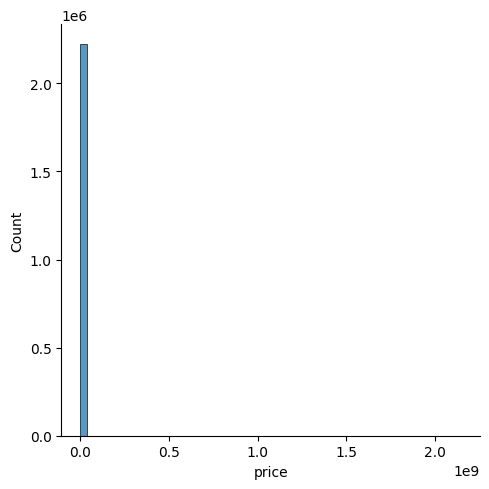

In [ ]:
plt.figure(figsize=(8, 6))
sns.displot(df.price,bins=60)
plt.show()
#

Try log transformation to mitigate the effect of extreme values which lead to enhance visualization specially because target variable has min value to (0) and max value to (2147483600.00).

The chart shows
*  Skewness to right and left.



<Figure size 800x600 with 0 Axes>

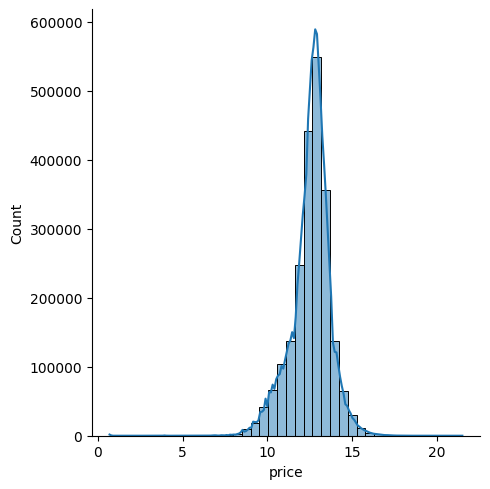

In [ ]:
plt.figure(figsize=(8, 6))
sns.displot(np.log1p(df[df['price'] != 0]['price']),bins=40,kde=True)# filtering 0 values suitable for log functions(log 0 is undefined)
plt.show()

**Plot the distribution of acre_lot to identify skewness.**

The acre_lot plot showed skewness to the right.

Use log transformation to mitigate the effect of extreme values for better visualisation.

<Figure size 800x600 with 0 Axes>

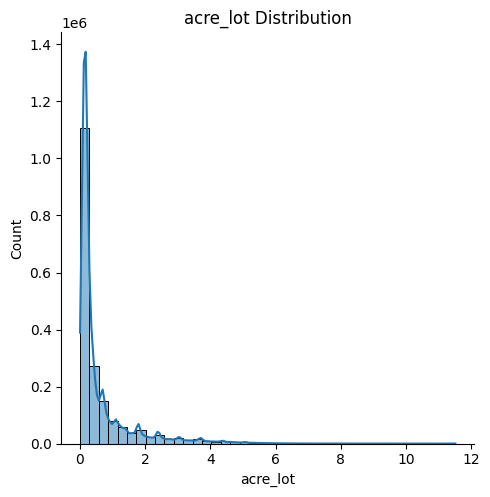

In [ ]:
plt.figure(figsize=(8, 6))
sns.displot(np.log1p(df[df['acre_lot'] !=0  & df['acre_lot'].notna()]['acre_lot']),bins=40,kde=True) # filtering 0 values suitable for log functions(log 0 is undefined)
plt.title('acre_lot Distribution')
plt.show()

**Plot the distribution of house_size to identify skewness.**

The house_size plot showed skewness to the right and left.
Use log transformation to mitigate the effect of ouliers for better visualisation.

<Figure size 800x600 with 0 Axes>

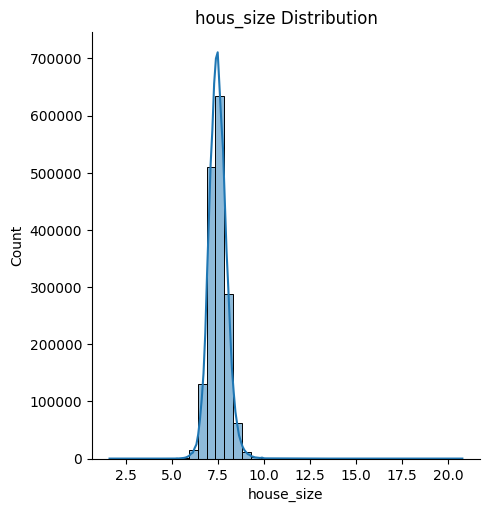

In [ ]:
plt.figure(figsize=(8, 6))
sns.displot(np.log1p(df[df['house_size'] != 0 & df['house_size'].notna()]['house_size']),bins=40,kde=True) # filtering 0 and NaN values suitable for log functions(log 0 is undefined)
plt.title('hous_size Distribution')
plt.show()

**Using countplot for comparing and ranking and distribution of discrete value among categories.**

This plot shows that the most houses has 3 bedrooms and comes in the second degree houses has 4 bedrooms.

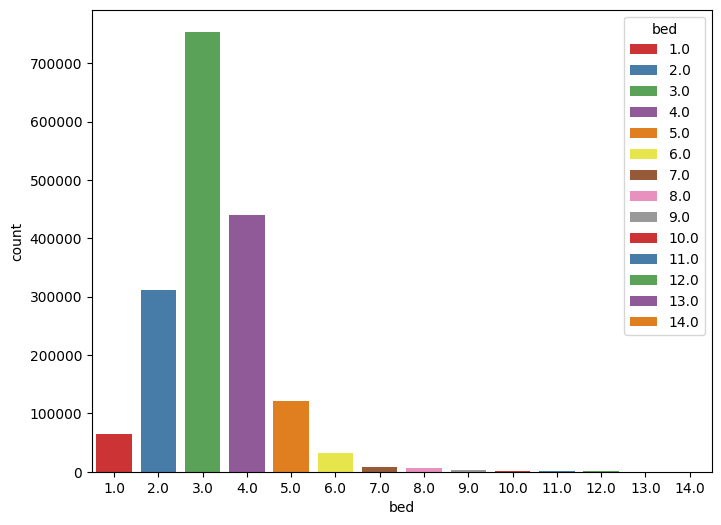

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='bed',data=df[df['bed']<15],hue='bed',palette='Set1')
plt.show()

This plot shows that most of houses have two bathrooms.

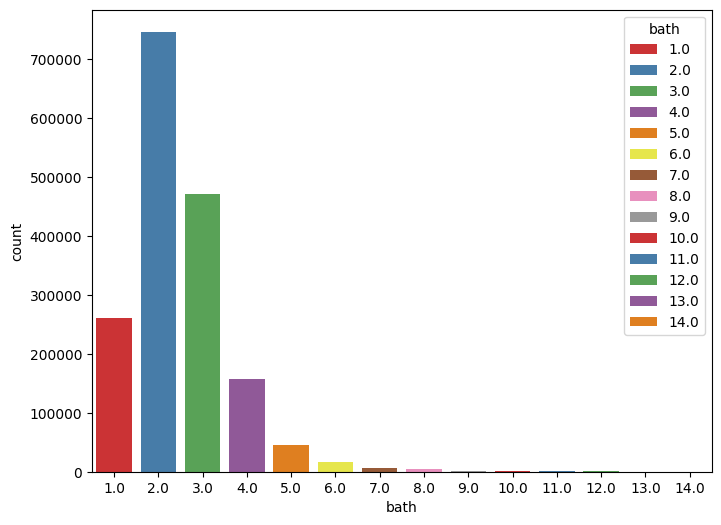

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='bath',data=df[df['bath']<15],hue='bath',palette='Set1')
plt.show()

# **Relationships between features and target variable:**

*   Boxplot: summerizing, visualizing the distribution of price per number of bedrooms. (most important to detect outliers).



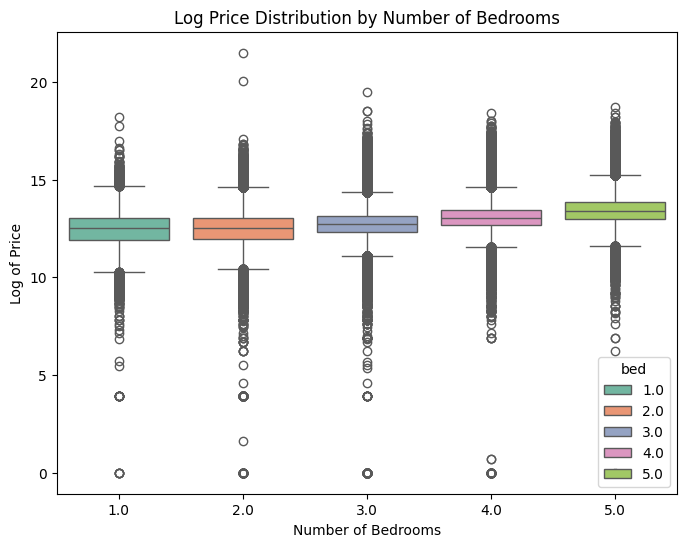

In [ ]:
# Filter out prices that are 0 or NaN, and beds that are NaN or too high for visualization
filtered_df = df[(df['price'] > 0) & (df['bed'].notna()) & (df['bed'] < 6)].copy()

# Apply log transformation to the filtered price
filtered_df['log_price'] = np.log(filtered_df['price'])
plt.figure(figsize=(8,6))
sns.boxplot(x='bed', y='log_price', data=filtered_df,hue='bed',palette='Set2')
plt.title('Log Price Distribution by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Log of Price')
plt.show()

The plot shows both the mean and Median price of houses per number of bedrooms and most important the two charts shows the **impact of outliers.**

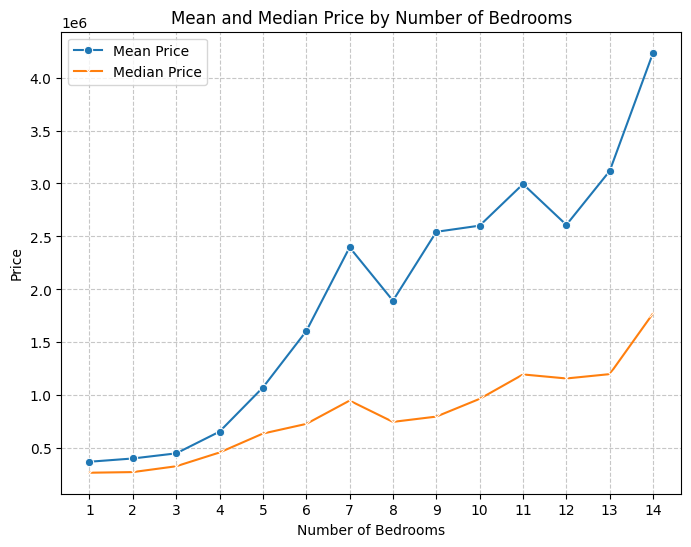

In [ ]:
df_prices_per_bed = df[df['bed'] < 15].groupby('bed')['price'].agg(['mean', 'median']).reset_index()

plt.figure(figsize=(8,6))
sns.lineplot(x='bed', y='mean', data=df_prices_per_bed, marker='o', label='Mean Price')
sns.lineplot(x='bed', y='median', data=df_prices_per_bed, marker='x', label='Median Price')
plt.title('Mean and Median Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_prices_per_bed['bed'].unique())
plt.legend()
plt.show()

Boxplot: summerizing, visualizing the distribution of price per number of Bathrooms. (most important to detect outliers).

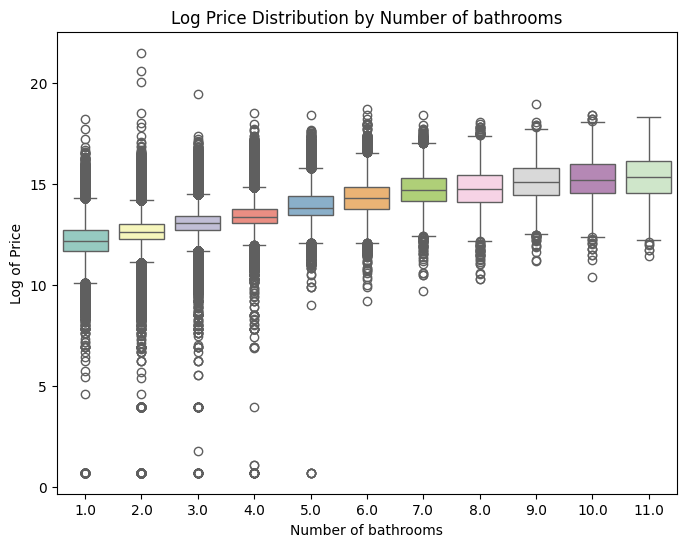

In [ ]:
# Filter out prices that are 0 or NaN, and baths that are NaN or too high for visualization
filtered_df = df[(df['price'] > 0) & (df['bath'].notna()) & (df['bath'] < 12)].copy()

# Apply log transformation to the filtered price
filtered_df['log_price'] = np.log1p(filtered_df['price'])
plt.figure(figsize=(8, 6))
sns.boxplot(x='bath', y='log_price', data=filtered_df,hue='bath',palette='Set3',legend=False)
plt.title('Log Price Distribution by Number of bathrooms')
plt.xlabel('Number of bathrooms')
plt.ylabel('Log of Price')
plt.show()

# Now showing mean and median Price distribution by **first 10 states**. **bold text**

In [ ]:
df_first_10_stats = df['state'].value_counts().sort_values(ascending=False).head(10).reset_index()
df_price_per_state = df_first_10_stats.merge(df.groupby('state')['price'].agg(['mean', 'median']).reset_index(), on='state')


In [ ]:
df_price_per_state.head(n=10)

,state,count,mean,median
0,Florida,249432,548206.79,319900.00
1,California,227215,1029223.70,669000.00
2,Texas,208335,441399.13,315000.00
3,New York,103159,943796.82,420000.00
4,North Carolina,85745,335128.82,249900.00
5,Illinois,85280,349957.60,249900.00
6,Georgia,80977,390382.86,299900.00
7,Pennsylvania,78373,331961.16,245000.00
8,Arizona,72825,485951.36,380000.00
9,Virginia,68763,468093.68,355000.00


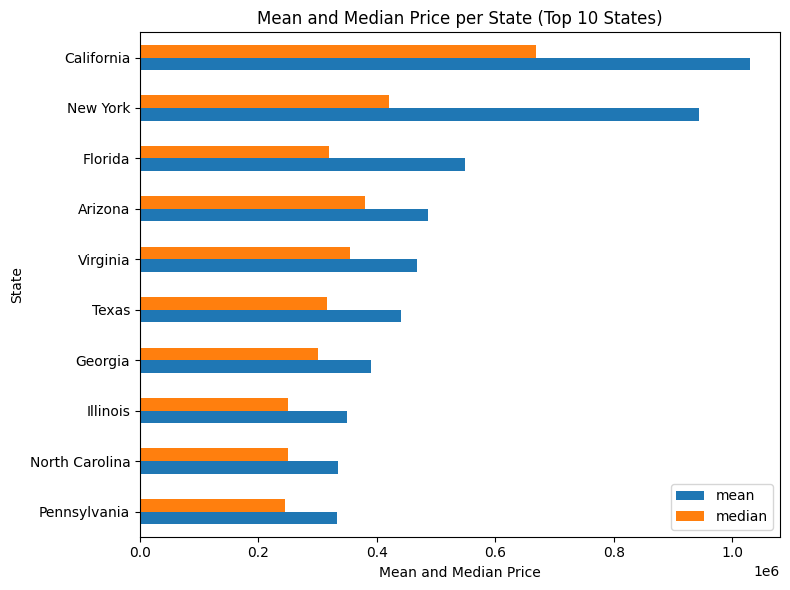

In [ ]:
df_price_per_state_sorted = df_price_per_state.sort_values(by='mean', ascending=True)
df_price_per_state_sorted.plot(x='state', y=['mean', 'median'], kind='barh', figsize=(8,6))
plt.title('Mean and Median Price per State (Top 10 States)')
plt.xlabel('Mean and Median Price')
plt.ylabel('State')
plt.tight_layout()
plt.show()

The Chart shows how the prices distributed by first 10 states and detect the outliers.

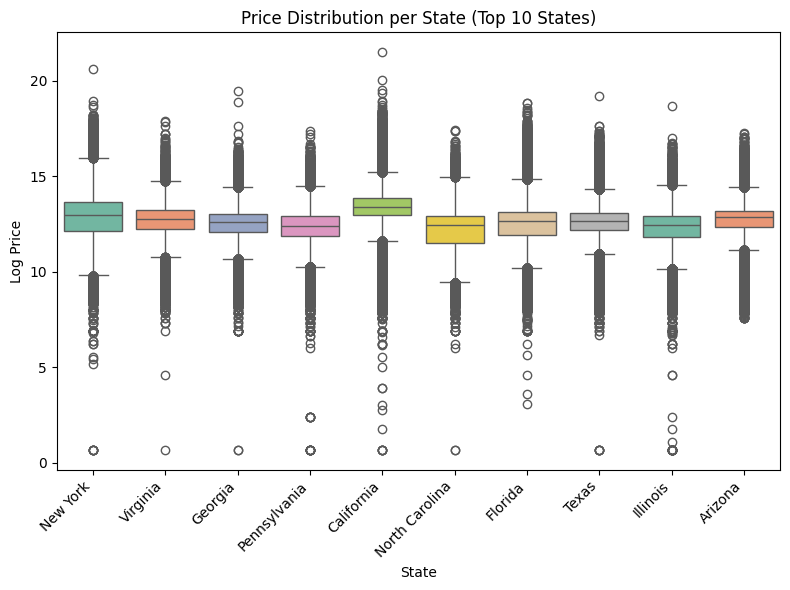

In [ ]:
top_10_states = df_first_10_stats['state'].tolist()
df_filtered_by_top_states = df[df['state'].isin(top_10_states)].copy()
df_filtered_by_top_states = df_filtered_by_top_states[df_filtered_by_top_states['price'] > 0]
df_filtered_by_top_states.loc[:, 'log_price'] = np.log1p(df_filtered_by_top_states['price'])
plt.figure(figsize=(8, 6))
sns.boxplot(x='state', y='log_price', data=df_filtered_by_top_states, hue='state', palette='Set2', legend=False)
plt.title('Price Distribution per State (Top 10 States)')
plt.xlabel('State')
plt.ylabel('Log Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# The relation between house_size and the price.


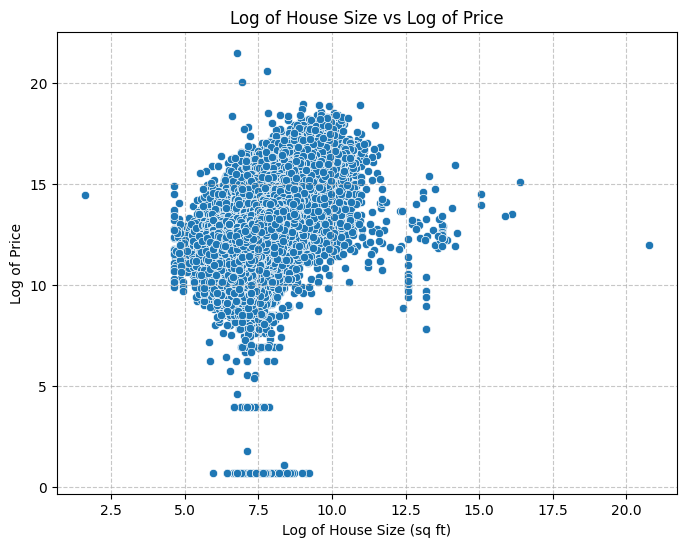

In [ ]:
#filtering data removing NaN values and zeros
filtered_df_size_price = df[(df['house_size'].notna()) & (df['house_size'] > 0) & (df['price'].notna()) & (df['price'] > 0)].copy()
#apply log trnsformation for visualization
filtered_df_size_price['log_house_size'] = np.log1p(filtered_df_size_price['house_size'])
filtered_df_size_price['log_price'] = np.log1p(filtered_df_size_price['price'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='log_house_size', y='log_price', data=filtered_df_size_price)
plt.xlabel('Log of House Size (sq ft)')
plt.ylabel('Log of Price')
plt.title('Log of House Size vs Log of Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Showing the relation between acre_lot  and the price.


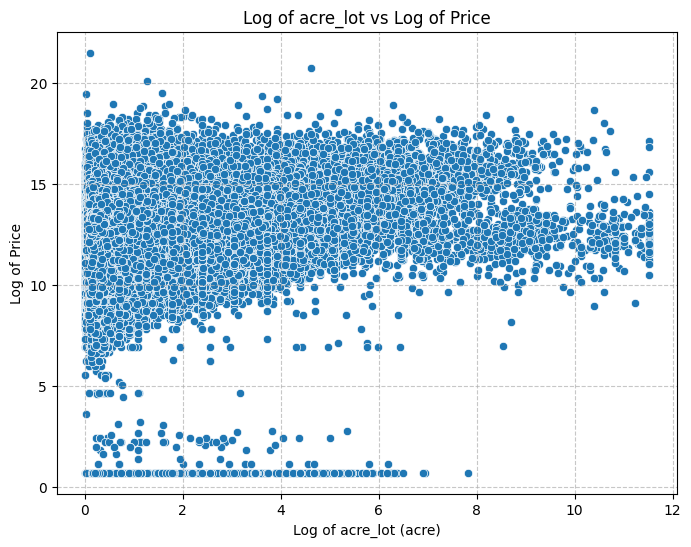

In [ ]:
#filtering data removing NaN values and zeros
filtered_df_acre_price = df[(df['acre_lot'].notna()) & (df['acre_lot'] > 0) & (df['price'].notna()) & (df['price'] > 0)].copy()
#apply log trnsformation for visualization
filtered_df_acre_price['log_acre_lot'] = np.log1p(filtered_df_acre_price['acre_lot'])
filtered_df_acre_price['log_price'] = np.log1p(filtered_df_acre_price['price'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='log_acre_lot', y='log_price', data=filtered_df_acre_price)
plt.xlabel('Log of acre_lot (acre)')
plt.ylabel('Log of Price')
plt.title('Log of acre_lot vs Log of Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **Mean price gouped by status**
This chart shows that the most houses sold slightly lower than the estimated price.

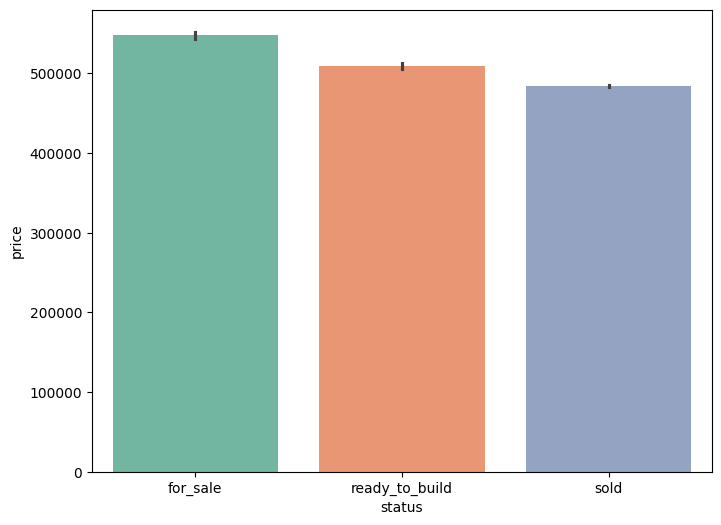

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(x='status',y='price',data=df,palette='Set2', hue='status',estimator='mean')
plt.show()

# How each category in status feature contribute to all

In [ ]:
df.status.value_counts() /len(df) *100 # percentage of each category

,count
status,
for_sale,62.40
sold,36.47
ready_to_build,1.13


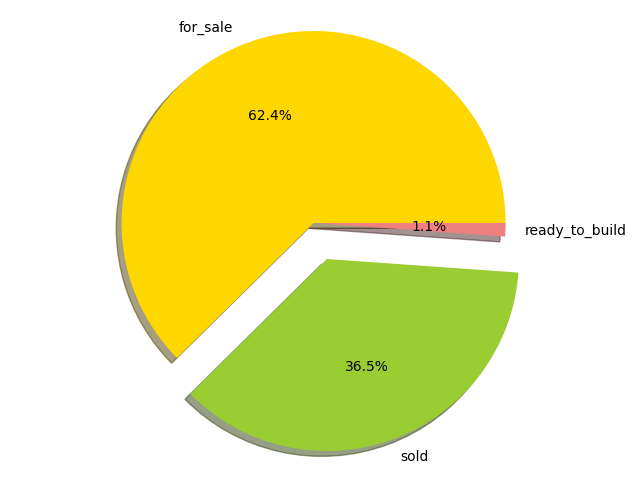

In [ ]:
labels=df.status.value_counts().index.tolist()
sizes=df.status.value_counts().values.tolist()
colors=['gold','yellowgreen','lightcoral']
explode=(0,0.2,0) ##move out the sold slice

##create apie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes,explode=explode,labels=labels,colors=colors,autopct="%1.1f%%",shadow=True)
plt.axis('equal')
plt.show()

# **Data Cleaning**

#**Calculating the percentage of missing value**


In [ ]:
(df.isnull().sum()/len(df))*100

,0
brokered_by,0.20
status,0.00
price,0.07
bed,21.62
bath,22.99
acre_lot,14.62
street,0.49
city,0.06
state,0.00
zip_code,0.01


In [ ]:
df.duplicated().sum() # check if there is duplicated rows

np.int64(0)

Columns that have missing values <1% it is most likely to drop these values

In [ ]:
df.dropna(subset=['price','street','zip_code','city','brokered_by','state'], inplace=True)

In [ ]:
df.isnull().sum()

,0
brokered_by,0
status,0
price,0
bed,474205
bath,503566
acre_lot,321631
street,0
city,0
state,0
zip_code,0


In [ ]:
df.shape[0]

2207981

In [ ]:
len(df[df['brokered_by']==0])

12

In [ ]:
df=df[df['brokered_by']!=0] ## delete zero encoded values

In [ ]:
df.isnull().sum()

,0
brokered_by,0
status,0
price,0
bed,474204
bath,503565
acre_lot,321631
street,0
city,0
state,0
zip_code,0


In [ ]:
df.price.describe() #descriptive statistics of price feature

,price
count,2207969.00
mean,521929.94
std,1572371.43
min,0.00
25%,165000.00
50%,325000.00
75%,550000.00
max,1000000000.00


# **Handling missing values of pre_sold_date**

In [ ]:
df.drop('prev_sold_date',axis=1,inplace=True)# drop it because has too many missing values

In [ ]:
df.isnull().sum()

,0
brokered_by,0
status,0
price,0
bed,474204
bath,503565
acre_lot,321631
street,0
city,0
state,0
zip_code,0


In [ ]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
0,103378.00,for_sale,105000.00,3.00,2.00,0.12,1962661.00,Adjuntas,Puerto Rico,601.00,920.00
1,52707.00,for_sale,80000.00,4.00,2.00,0.08,1902874.00,Adjuntas,Puerto Rico,601.00,1527.00
2,103379.00,for_sale,67000.00,2.00,1.00,0.15,1404990.00,Juana Diaz,Puerto Rico,795.00,748.00
3,31239.00,for_sale,145000.00,4.00,2.00,0.10,1947675.00,Ponce,Puerto Rico,731.00,1800.00
4,34632.00,for_sale,65000.00,6.00,2.00,0.05,331151.00,Mayaguez,Puerto Rico,680.00,NaN


# **Target feature (Price)**

# Removing the top 1% luxury properties

In [ ]:
print(f'{len(df[(df['price'] > 5000000) | (df['price'] <10000 )])} rows removed')
df = df[(df['price'] <= 5000000) & (df['price'] >= 10000)] #remove extreme values (outliers)


32157 rows removed


In [ ]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
0,103378.00,for_sale,105000.00,3.00,2.00,0.12,1962661.00,Adjuntas,Puerto Rico,601.00,920.00
1,52707.00,for_sale,80000.00,4.00,2.00,0.08,1902874.00,Adjuntas,Puerto Rico,601.00,1527.00
2,103379.00,for_sale,67000.00,2.00,1.00,0.15,1404990.00,Juana Diaz,Puerto Rico,795.00,748.00
3,31239.00,for_sale,145000.00,4.00,2.00,0.10,1947675.00,Ponce,Puerto Rico,731.00,1800.00
4,34632.00,for_sale,65000.00,6.00,2.00,0.05,331151.00,Mayaguez,Puerto Rico,680.00,NaN


# **Handling bed and bath missing values**

In [ ]:
df.shape[0]

2175812

In [ ]:
# Group-wise median imputation for bed
df['bed']=df.groupby(['state','city','zip_code'])['bed'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

# Fill any remaining NaN values with the global mode
global_mode_bed = df['bed'].mode()[0]
df['bed']=df['bed'].fillna(global_mode_bed)


In [ ]:
## Group-wise median imputation for bath
df['bath']=df.groupby(['state','city','zip_code'])['bath'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))

# Fill any remaining NaN values with the global mode
global_mode_bath = df['bath'].mode()[0]
df['bath']=df['bath'].fillna(global_mode_bath)

In [ ]:
df.isnull().sum()

,0
brokered_by,0
status,0
price,0
bed,0
bath,0
acre_lot,317220
street,0
city,0
state,0
zip_code,0


# **Dealing with missing values of house_size and acre_lot**

In [ ]:
df['house_size_missing'] = df['house_size'].isna().astype(int) #add indicator

# Create a temporary 'sqft_price_per_unit' column in the main dataframe
df['sqft_price_per_unit'] = np.nan
mask = (df['house_size'].notna()) & (df['house_size'] > 0) & (df['price'].notna()) & (df['price'] > 0)# detrmine rows
df.loc[mask,'sqft_price_per_unit'] = df['price'] / df['house_size'] #compute price per sqft

# Calculate the mean sqft_price_per_unit grouped by 'state'
df_state_mean_sqft_price = df.groupby('state')['sqft_price_per_unit'].transform('mean') # transform return same shape of dataframe used instead of apply

# Impute missing 'house_size' values where 'house_size' is NaN and 'price' is available,
mask1 = df['house_size'].isna() & df['price'].notna() & df_state_mean_sqft_price.notna()

df.loc[mask1,'house_size'] = df.loc[mask1,'price'] / df_state_mean_sqft_price.loc[mask1]

# Fill any remaining NaN values in 'house_size' with the global median of 'house_size'
global_house_size_median = df['house_size'].median()
df['house_size'] = df['house_size'].fillna(global_house_size_median)

# Drop the temporary 'sqft_price_per_unit' column
df.drop(columns=['sqft_price_per_unit'], inplace=True)

In [ ]:
len(df.street.unique())

1967068

In [ ]:
# Group-wise median imputation for 'acre_lot'
df["acre_lot_missing"] = df["acre_lot"].isna().astype(int) #add indicator
df["acre_lot"] = df.groupby(["city", "bed", "bath"])["acre_lot"].transform(lambda x: x.fillna(x.median()))

# Fill any remaining value with global median
global_acre_lot_median = df['acre_lot'].median()
df['acre_lot']=df['acre_lot'].fillna(global_acre_lot_median)

# **Categorical Variables and Dummy Variables**




# Status feature

In [ ]:
dummies_status=pd.get_dummies(df['status'],drop_first=True) # applying one-hot-encoding because low cardinality
df=pd.concat([df.drop('status',axis=1),dummies_status],axis=1) # drop the main row and concatenate dummies features created

In [ ]:
dummies_status.sold.unique()

array([False,  True])

In [ ]:
df.head()

,brokered_by,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,house_size_missing,acre_lot_missing,ready_to_build,sold
0,103378.00,105000.00,3.00,2.00,0.12,1962661.00,Adjuntas,Puerto Rico,601.00,920.00,0,0,False,False
1,52707.00,80000.00,4.00,2.00,0.08,1902874.00,Adjuntas,Puerto Rico,601.00,1527.00,0,0,False,False
2,103379.00,67000.00,2.00,1.00,0.15,1404990.00,Juana Diaz,Puerto Rico,795.00,748.00,0,0,False,False
3,31239.00,145000.00,4.00,2.00,0.10,1947675.00,Ponce,Puerto Rico,731.00,1800.00,0,0,False,False
4,34632.00,65000.00,6.00,2.00,0.05,331151.00,Mayaguez,Puerto Rico,680.00,318.67,1,0,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175812 entries, 0 to 2226381
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   brokered_by         float64
 1   price               float64
 2   bed                 float64
 3   bath                float64
 4   acre_lot            float64
 5   street              float64
 6   city                object 
 7   state               object 
 8   zip_code            float64
 9   house_size          float64
 10  house_size_missing  int64  
 11  acre_lot_missing    int64  
 12  ready_to_build      bool   
 13  sold                bool   
dtypes: bool(2), float64(8), int64(2), object(2)
memory usage: 284.5+ MB


# Target Encoding for stat and city Categorical Features

Using Target encoding instead of one-hot encoding is very effective for high-cardinality categorical features like `city` and `state`.

In [ ]:
def target_encode(df, column, target_column):

    # Calculate mean target value for each category
    target_mean_map = df.groupby(column)[target_column].mean().to_dict()

    # Get the global mean of the target column
    global_mean = df[target_column].mean()

    # Apply the encoding, fill NAN with global_mean
    df[f'{column}_encoded'] = df[column].map(target_mean_map).fillna(global_mean)

    return df, target_mean_map

# Apply target encoding to 'state' and 'city'
df, state_encoding_map = target_encode(df, 'state', 'price')
df, city_encoding_map = target_encode(df, 'city', 'price')

# Drop the original 'state' and 'city' columns
df.drop(['state', 'city'], axis=1, inplace=True)

display(df.head())
df.info()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,house_size_missing,acre_lot_missing,ready_to_build,sold,state_encoded,city_encoded
0,103378.00,105000.00,3.00,2.00,0.12,1962661.00,601.00,920.00,0,0,False,False,437079.97,92500.00
1,52707.00,80000.00,4.00,2.00,0.08,1902874.00,601.00,1527.00,0,0,False,False,437079.97,92500.00
2,103379.00,67000.00,2.00,1.00,0.15,1404990.00,795.00,748.00,0,0,False,False,437079.97,109105.88
3,31239.00,145000.00,4.00,2.00,0.10,1947675.00,731.00,1800.00,0,0,False,False,437079.97,220297.33
4,34632.00,65000.00,6.00,2.00,0.05,331151.00,680.00,318.67,1,0,False,False,437079.97,169878.20


<class 'pandas.core.frame.DataFrame'>
Index: 2175812 entries, 0 to 2226381
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   brokered_by         float64
 1   price               float64
 2   bed                 float64
 3   bath                float64
 4   acre_lot            float64
 5   street              float64
 6   zip_code            float64
 7   house_size          float64
 8   house_size_missing  int64  
 9   acre_lot_missing    int64  
 10  ready_to_build      bool   
 11  sold                bool   
 12  state_encoded       float64
 13  city_encoded        float64
dtypes: bool(2), float64(10), int64(2)
memory usage: 284.5 MB


# **Feature engineering**



*   As there is medium relationships between house_size and price we can create feature:
sqft_price= price/house_size

*  As bed and bath also contribute to the price of house we can add feacture represent number of rooms:
rooms_nbr=bath + bed



In [ ]:
df['rooms_nbr']=df['bath']+df['bed'] # create new feature rooms_nbr

In [ ]:
df['ratio_bed_bath']=df['bed']/(df['bath']) # create new feature ratio_bed_bath

In [ ]:
df['size_per_bed']=df['house_size']/df['bed'] # create new feature size_per_bed

In [ ]:
df.head()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size,house_size_missing,acre_lot_missing,ready_to_build,sold,state_encoded,city_encoded,rooms_nbr,ratio_bed_bath,size_per_bed
0,103378.00,105000.00,3.00,2.00,0.12,1962661.00,601.00,920.00,0,0,False,False,437079.97,92500.00,5.00,1.50,306.67
1,52707.00,80000.00,4.00,2.00,0.08,1902874.00,601.00,1527.00,0,0,False,False,437079.97,92500.00,6.00,2.00,381.75
2,103379.00,67000.00,2.00,1.00,0.15,1404990.00,795.00,748.00,0,0,False,False,437079.97,109105.88,3.00,2.00,374.00
3,31239.00,145000.00,4.00,2.00,0.10,1947675.00,731.00,1800.00,0,0,False,False,437079.97,220297.33,6.00,2.00,450.00
4,34632.00,65000.00,6.00,2.00,0.05,331151.00,680.00,318.67,1,0,False,False,437079.97,169878.20,8.00,3.00,53.11


In [ ]:
df.isnull().sum()

,0
brokered_by,0
price,0
bed,0
bath,0
acre_lot,0
street,0
zip_code,0
house_size,0
house_size_missing,0
acre_lot_missing,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2175812 entries, 0 to 2226381
Data columns (total 17 columns):
 #   Column              Dtype  
---  ------              -----  
 0   brokered_by         float64
 1   price               float64
 2   bed                 float64
 3   bath                float64
 4   acre_lot            float64
 5   street              float64
 6   zip_code            float64
 7   house_size          float64
 8   house_size_missing  int64  
 9   acre_lot_missing    int64  
 10  ready_to_build      bool   
 11  sold                bool   
 12  state_encoded       float64
 13  city_encoded        float64
 14  rooms_nbr           float64
 15  ratio_bed_bath      float64
 16  size_per_bed        float64
dtypes: bool(2), float64(13), int64(2)
memory usage: 334.3 MB


# **Relationships between the features**

Heatmap with color intensity immediately shows strength and direction of correlations.



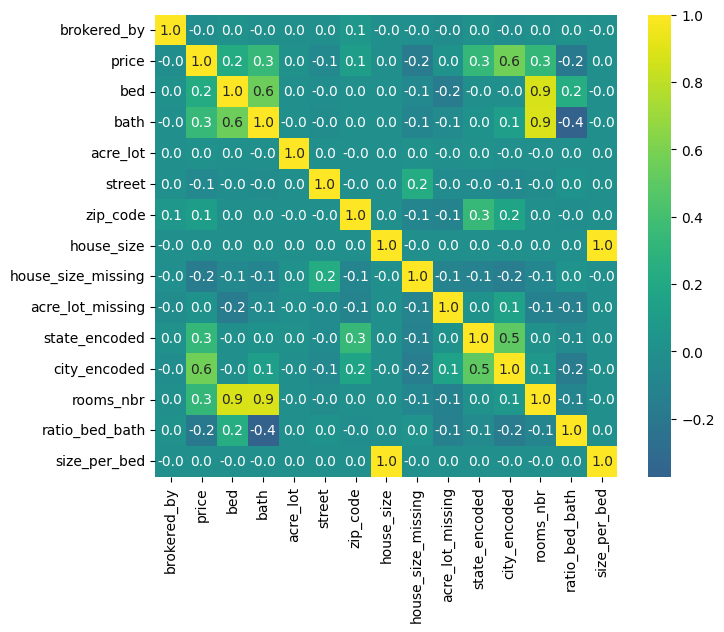

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='viridis',fmt='.1f',center=0,square=True)
plt.show()

# **Relations between Features and Price**

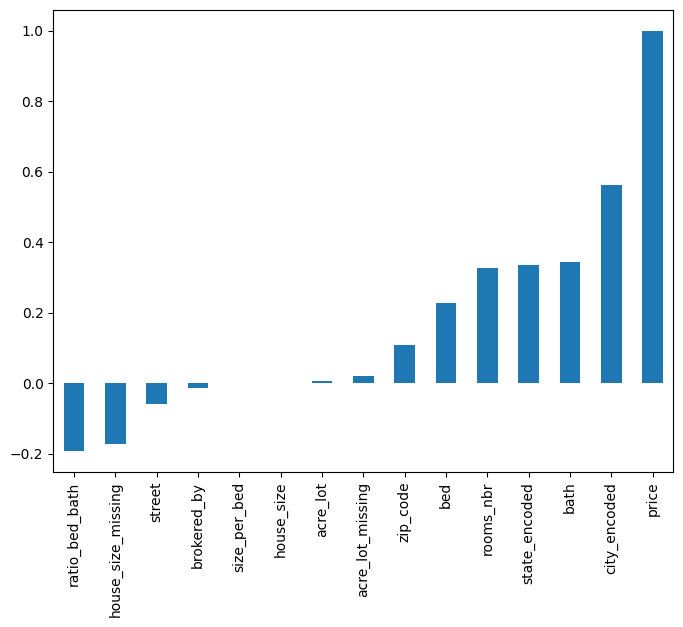

In [ ]:
plt.figure(figsize=(8, 6))
df.select_dtypes(include=np.number).corr()['price'].sort_values().reindex().plot(kind='bar')
plt.show()

# **Conslusions:**

1.   Using Linear Model doesn't suitable because there are too many outliers in features and Linear Regression in sensitive to outliers.

2.  In this case we cann't use simple models like Linear Regression, we should try using complex model that can detect the hidden patterns and interactions between features like RandomForest or LightGBM, this model can discover nonlinearity and interactions between features and more robust to outliers.








### **Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# prepair features and target variable
X=df.drop('price',axis=1)
y=np.log1p(df['price'])# use Log transformation it can enhancing performance of RandomForest

In [ ]:
# split our X and y datasets to train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [ ]:
X_train.shape

(1305487, 16)

# **LightGBM (Large Dataset - Boosting)**

It is optimized for speed, it used:


*   Histogram-based splitting value.
*   Leaf-wise tree growth.
*   Better memory optimization.
*   Parallel processing.





In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_log_error

In [ ]:
lgbm=LGBMRegressor(random_state=101)

In [ ]:
lgbm.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051204 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2045
[LightGBM] [Info] Number of data points in the train set: 1305487, number of used features: 16
[LightGBM] [Info] Start training from score 12.563499


LGBMRegressor(random_state=101)

In [ ]:
preds=lgbm.predict(X_test)

In [ ]:
lgbm.score(X_train,y_train) # train score

0.8904820064227095

In [ ]:
r2_score(y_test,preds) # test score

0.8908191653936101

In [ ]:
real_predictions = np.expm1(preds)
real_y_test = np.expm1(y_test)

In [ ]:
mean_absolute_error(real_y_test,real_predictions)

114719.897598128

# **RandomForest**      (as it is more robust for outliers - Bagging)



## **Hyperparameter Optimization with Optuna for Random Forest**

  **Params:**

  n_estimators: 200
  max_depth: 30
  min_samples_leaf: 2
  min_samples_split: 5
  max_features: 0.8271644699056845**


Optimized Random Forest Training R^2: 0.9781239505625666
Optimized Random Forest Test R^2: 0.925278479490632

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [ ]:
# create model
rf_optimized=RandomForestRegressor(n_estimators=200,max_depth=30,min_samples_leaf=2,min_samples_split=5,max_features=0.8271644699056845,random_state=101)

In [ ]:
rf_optimized.fit(X_train,y_train)

RandomForestRegressor(max_depth=30, max_features=0.8271644699056845,
                      min_samples_leaf=2, min_samples_split=5, n_estimators=200,
                      random_state=101)

In [ ]:
predictions_optimized=rf_optimized.predict(X_test)

# **Make Predictions**

In [ ]:
rf_optimized.score(X_train,y_train) # train score

0.9781136531858218

# **Evaluation**

In [ ]:
r2_score(y_test,predictions_optimized) # test score

0.9253722254222513

In [ ]:
# Inverese predictions to real values in $
predictions = np.expm1(predictions_optimized)
y_test_real = np.expm1(y_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
mean_absolute_error(y_test_real,predictions)

84356.66630764345

In [ ]:
df['price'].mean()

np.float64(463167.1240057459)

# **Brief:**
RandomForest: By comparing *MAE with mean price* of houses, Model predict the price of house with error approximately **85000$**, slower.

LightGBM : By comparing *MAE with mean price* of houses, Model predict the price of house with error approximately **115000$**, very fast.

# **Save Model**

In [ ]:
if False:
 import joblib

# Define a filename for the model

 model_filename = '/content/drive/MyDrive/rf_optimized.joblib'
 model_filename = '/content/drive/MyDrive/lgbm_REstate.joblib'

# Save the trained model to a file

 joblib.dump(rf_optimized, model_filename)
 joblib.dump(lgbm, model_filename)

print(f"Model saved successfully to {model_filename}")

Model saved successfully to /content/drive/MyDrive/lgbm_REstate.joblib


# **Load the model**

In [ ]:
import joblib
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor


rf_optimized=RandomForestRegressor() # create model
rf_optimized=joblib.load('/content/drive/MyDrive/rf_optimized.joblib') # load model

lgbm=LGBMRegressor()
lgbm=joblib.load('/content/drive/MyDrive/lgbm_REstate.joblib') # load model

print("model loaded successfully")

model loaded successfully


### **Feature Importance from LightGBM Model**

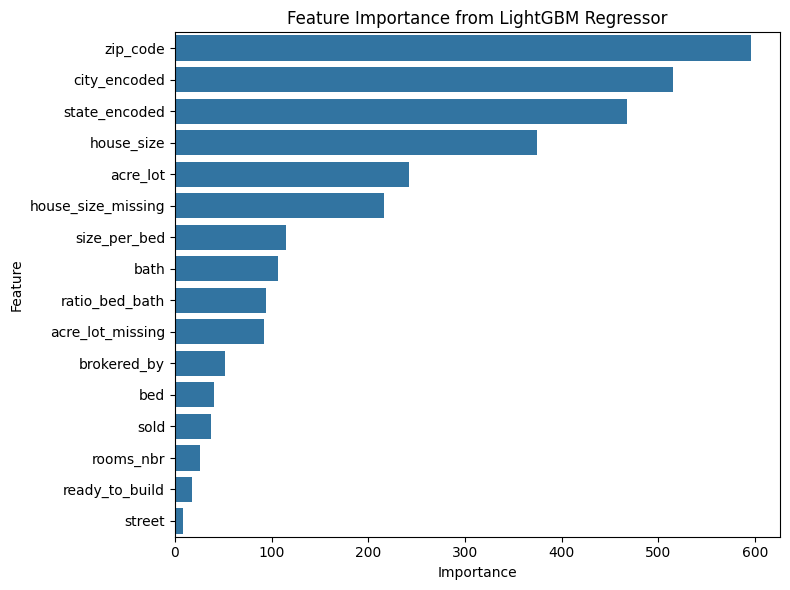

In [ ]:
feature_importances = lgbm.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_lgbm = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df_lgbm = importance_df_lgbm.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_lgbm)
plt.title('Feature Importance from LightGBM Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **Feature Importance from RandomForest Model**

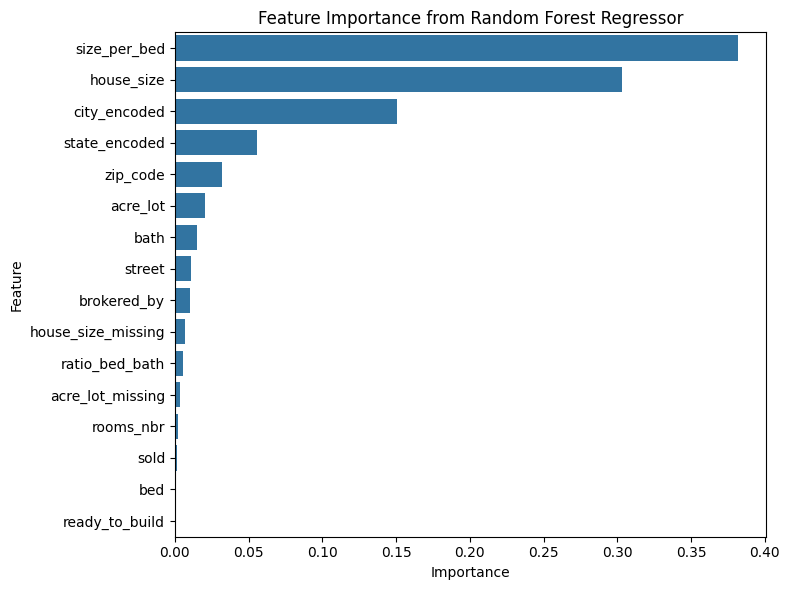

In [ ]:
feature_importances = rf_optimized.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_rf)
plt.title('Feature Importance from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# **Intialising API_KEY and operAI client**

In [ ]:
from openai import OpenAI
from google.colab import userdata

# Configure openai client
openai_api_key = userdata.get("OPENAI_API_KEY")
openai_client = OpenAI(api_key=openai_api_key)
print("OpenAI client successfully configured.")

OpenAI client successfully configured.


#**Retrival-Augmanted Generative (RAG)**

Convert our DataFrame into a collection of text documents.

 ChromaDB is vector database to store these documents and their embeddings.

In [ ]:
print("Installing necessary libraries...")
!pip install -q langchain langchain-openai openai chromadb gradio langchain-community langchain_chroma
print("Libraries installed successfully!")

Installing necessary libraries...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.3/558.3 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
!pip install --upgrade openai  langchain langchain_community langchain_chroma -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.9/136.9 kB 7.7 MB/s eta 0:00:00


## **Integrating with LangChain for RAG**

This involves using LangChain's `Document` objects, embedding models, and retrieval chains.

In [ ]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_classic.chains.qa_with_sources.retrieval import RetrievalQAWithSourcesChain

# **Dealing with DataSet Contains Images like Socal2**

In [ ]:
# Re-unzip the files to ensure they are present and overwrite any existing ones.
# Assuming cell_images.zip extracts into a 'cell_images' directory inside /content/.
socal2 = !unzip -o /content/drive/MyDrive/archive.zip

In [ ]:
df_images=pd.read_csv("/content/drive/MyDrive/socal2.csv")

In [ ]:
print("\nColumns in df_image:", df_images.columns)


Columns in df_image: Index(['image_id', 'street', 'citi', 'n_citi', 'bed', 'bath', 'sqft', 'price'], dtype='object')


In [ ]:
df_images.drop('n_citi',axis=1,inplace=True)

In [ ]:
df_images.columns

Index(['image_id', 'street', 'citi', 'bed', 'bath', 'sqft', 'price'], dtype='object')

In [ ]:
df_images = df_images.rename(columns={'sqft': 'house_size','citi':'city'})

df_images

,image_id,street,city,bed,bath,house_size,price
0,0,1317 Van Buren Avenue,"Salton City, CA",3,2.00,1560,201900
1,1,124 C Street W,"Brawley, CA",3,2.00,713,228500
2,2,2304 Clark Road,"Imperial, CA",3,1.00,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",3,1.00,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",4,3.00,2547,385100
...,...,...,...,...,...,...,...
15469,15469,4156 Sterlingview Drive,"Moorpark, CA",5,4.10,4092,949000
15470,15470,4355 Avenida Prado,"Thousand Oaks, CA",5,3.00,2773,949900
15471,15471,12717 Koenigstein Rd Road,"Santa Paula, CA",3,2.00,1576,920000
15472,15472,36 Kunkle Street,"Oak View, CA",4,2.00,2086,997000


In [ ]:
len(df_images)

15474

In [ ]:
df_images.isnull().sum()

,0
image_id,0
street,0
city,0
bed,0
bath,0
house_size,0
price,0


# **Define IMAGES Path**

In [ ]:
# Define the directory where images are extracted from 'archive.zip'.
IMAGE_DIR = "/content/socal2/socal_pics/"

# Verify the image directory exists
if not os.path.exists(IMAGE_DIR):
    pass # Removed warning print
else:
    print(f"Image directory found at {IMAGE_DIR}.")

Image directory found at /content/socal2/socal_pics/.


## **Using BLIP-2 for Image Description**


In [ ]:
from transformers import Blip2ForConditionalGeneration, Blip2Processor
import torch

# Load pre-trained BLIP-2 model and processor
print("Loading Salesforce/blip2-opt-2.7b model and processor...")

# Using a smaller BLIP-2 model for memory efficiency
model_id = "Salesforce/blip2-opt-2.7b"

blip_model = Blip2ForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16, # Use float16 for memory efficiency
    device_map="auto"
)
blip_processor = Blip2Processor.from_pretrained(model_id)

print("Salesforce/blip2-opt-2.7b model and processor loaded successfully!")

Loading Salesforce/blip2-opt-2.7b model and processor...


config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

Salesforce/blip2-opt-2.7b model and processor loaded successfully!


In [ ]:
import os
from PIL import Image
from tqdm.notebook import tqdm # Import tqdm here for the batch function

def get_image_descriptions_batch(image_paths_and_ids, batch_size=16):
    """Generates text descriptions for a list of images using the loaded BLIP-2 model in batches.
    Args:
        image_paths_and_and_ids: A list of tuples, where each tuple is (image_path, image_id).
        batch_size: The number of images to process in each batch.
    Returns:
        A dictionary mapping image_id to its description string.
    """
    batch_descriptions = {}
    # Updated prompt to include strengths, weaknesses, estimated conditions, style, and type of buyer
    prompt = "Question: Analyze this property image, listing its strengths, weaknesses, estimated conditions, style, and the type of buyer who would likely be interested, along with a detailed description including architectural style, key features, outdoor spaces, interior design, and overall ambiance. Provide the answer as a bulleted list. Answer:"

    for i in tqdm(range(0, len(image_paths_and_ids), batch_size), desc="Generating image descriptions in batches"):
        current_batch_paths_ids = image_paths_and_ids[i:i+batch_size]
        batch_images = []
        original_image_ids_in_batch = []

        for path, image_id in current_batch_paths_ids:
            try:
                image = Image.open(path).convert("RGB")
                batch_images.append(image)
                original_image_ids_in_batch.append(image_id)
            except FileNotFoundError:
                # If file not found, store empty string for this image_id
                batch_descriptions[image_id] = ""
                continue
            except Exception as e:
                # Removed debug print: print(f"Error opening image {path}: {e}. Skipping.")
                batch_descriptions[image_id] = ""
                continue

        if not batch_images:
            continue

        # Prepare inputs for BLIP-2
        inputs = blip_processor(images=batch_images, text=prompt, return_tensors="pt").to(blip_model.device)

        # Generate description using BLIP-2 model
        generated_ids = blip_model.generate(
            **inputs,
            max_new_tokens=50,
            min_new_tokens=25,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.95
        )

        # Decode the generated text
        decoded_texts = blip_processor.batch_decode(generated_ids, skip_special_tokens=True)

        for j, text in enumerate(decoded_texts):
            original_id = original_image_ids_in_batch[j]
            description = text.replace(prompt, "").strip()
            batch_descriptions[original_id] = f"Image description: {description}."
    return batch_descriptions

### **Creating LangChain Document Objects**

We need to convert our property data into LangChain's `Document` format. Each `Document` will have `page_content` (the descriptive text) and `metadata` (additional structured information).

In [ ]:
from tqdm.notebook import tqdm # For progress bar

documents = []
all_image_paths_and_ids = []
all_image_rows = [] # To keep original row data associated for document creation

print(f"Preparing image data for batch processing...")
for index, row in df_images.iterrows():
    image_id = row['image_id']
    image_filename = f"{int(image_id)}.jpg"
    image_path = os.path.join(IMAGE_DIR, image_filename)
    all_image_paths_and_ids.append((image_path, image_id))
    all_image_rows.append(row) # Store the full row for later Document creation

print(f"Generating descriptions for {len(all_image_paths_and_ids)} images in batches using BLIP-2. This may take a while.")

# Use the batch description function
image_descriptions_map = get_image_descriptions_batch(all_image_paths_and_ids, batch_size=1) # Using a default batch_size of 32

print(f"Creating LangChain Documents for {len(all_image_paths_and_ids)} properties.")
for i, row in tqdm(enumerate(all_image_rows), total=len(all_image_rows), desc="Creating LangChain Documents"):
    image_id = row['image_id']
    image_description = image_descriptions_map.get(image_id, "") # Get description from map

    if image_description:
        image_description_text = f"{image_description} "
        #print(f"{image_description_text}\n")
    else:
        image_description_text = "(No image description available). " # Indicate if description failed

    # Construct the document string for page_content
    page_content = (
        f"{image_description_text}"
        f"This property is located at {row['street']} in {row['city']}. "
        f"It has {row['bed']} bedrooms and {row['bath']} bathrooms. "
        f"The house size is approximately {row['house_size']:.0f} square feet. "
        f"The listing price is ${row['price']:.2f}."
    )

    # Prepare metadata for the Document using only columns available in df_images
    metadata = {
        "price": row['price'],
        "bed": row['bed'],
        "bath": row['bath'],
        "city": row['city'],
        "house_size": row['house_size'],
        "street": row['street'],
        "image_id": row['image_id'],
        "source": f"property_id_{image_id}" # A unique identifier for the source
    }
    documents.append(Document(page_content=page_content, metadata=metadata))

print(f"Created {len(documents)} LangChain Document objects with image descriptions.")
print("\nExample LangChain Document:")
print(f"{documents[0]}\n")

Preparing image data for batch processing...
Generating descriptions for 15474 images in batches using BLIP-2. This may take a while.


Generating image descriptions in batches:   0%|          | 0/15474 [00:00<?, ?it/s]

Creating LangChain Documents for 15474 properties.


Creating LangChain Documents:   0%|          | 0/15474 [00:00<?, ?it/s]

Created 15474 LangChain Document objects with image descriptions.

Example LangChain Document:
page_content='Image description: This image shows the exterior of a building in a major city. You can see the building's address, the size of the unit, and the exterior of the building. It's also important to describe what you would consider a major or minor problem.. This property is located at 1317 Van Buren Avenue in Salton City, CA. It has 3 bedrooms and 2.0 bathrooms. The house size is approximately 1560 square feet. The listing price is $201900.00.' metadata={'price': 201900, 'bed': 3, 'bath': 2.0, 'city': 'Salton City, CA', 'house_size': 1560, 'street': '1317 Van Buren Avenue', 'image_id': 0, 'source': 'property_id_0'}



### **Storing LangChain Documents in ChromaDB**



 `documents` include image descriptions, This ensures the visual context from the images is now embedded and searchable.

In [ ]:
# Define a directory for persistence
CHROMA_DB_PATH = "/content/drive/MyDrive/chroma_db_Re"

# Ensure the directory exists
if not os.path.exists(CHROMA_DB_PATH):
    os.makedirs(CHROMA_DB_PATH)

# Initialize OpenAI Embeddings
embeddings = OpenAIEmbeddings(openai_api_key=openai_api_key)
print("OpenAIEmbeddings initialized.")

# Create/Load the ChromaDB vector store with OpenAI embeddings and persistence
# If a persistent directory is provided, Chroma will load existing data or create a new one if it doesn't exist.
#vector_store = Chroma.from_documents(documents = documents, embedding = embeddings, persist_directory=CHROMA_DB_PATH)
vector_store = Chroma(persist_directory=CHROMA_DB_PATH, embedding_function=embeddings)
print("ChromaDB vector store created/loaded successfully.")



# Verify the number of items in the store
vector_count = vector_store._collection.count()
print(f"ChromaDB vector store created/loaded with {vector_count} items and persisted to {CHROMA_DB_PATH}.")

if vector_count == 0:
    raise ValueError("Vector store creation resulted in 0 items. Check previous steps.")

OpenAIEmbeddings initialized.
ChromaDB vector store created/loaded successfully.
ChromaDB vector store created/loaded with 15474 items and persisted to /content/drive/MyDrive/chroma_db_Re.


# **Test Vector Database**

In [ ]:
# retrieve the first chunk of stored data from the vector store
stored_data = vector_store._collection.get(include=["embeddings", "documents"],limit=1) # return a dictionary
# and limit the results just to one
# Display the results
print("First chunk text:\n", stored_data['documents'][0])
print("\nEmbedding vector:\n", stored_data['embeddings'][0])
print(f"\nFull embedding has {len(stored_data['embeddings'][0])} dimensions.")

First chunk text:
 Image description: This image shows the exterior of a building in a major city. You can see the building's address, the size of the unit, and the exterior of the building. It's also important to describe what you would consider a major or minor problem.. This property is located at 1317 Van Buren Avenue in Salton City, CA. It has 3 bedrooms and 2.0 bathrooms. The house size is approximately 1560 square feet. The listing price is $201900.00.

Embedding vector:
 [ 0.0064945   0.01997502 -0.00078396 ... -0.02325176 -0.02996253
 -0.04744723]

Full embedding has 1536 dimensions.


### **Setting up a RetrievalQA Chain**

 This chain can answer questions by first retrieving relevant documents and then generating a response based on those documents.

In [ ]:
# Create a retriever from the ChromaDB vector store
retriever = vector_store.as_retriever(search_kwargs={"k": 3}) # Retrieve top 3 relevant documents
print("Retriever configured successfully from vector store.")

# Initialize ChatOpenAI LLM
llm = ChatOpenAI(openai_api_key=openai_api_key, model_name="gpt-3.5-turbo", temperature=0.4)
print("ChatOpenAI LLM initialized.")

# Create the RetrievalQA chain
qa_chain = RetrievalQAWithSourcesChain.from_chain_type(llm = llm,
                                                       chain_type = "stuff",
                                                       retriever = retriever,
                                                       return_source_documents = True,  # Request the actual Document objects used
                                                       verbose = False)  # Set to True to see Langchain's internal steps (can be noisy)

print("LangChain RetrievalQA chain initialized.")

Retriever configured successfully from vector store.
ChatOpenAI LLM initialized.
LangChain RetrievalQA chain initialized.


# **Integrating SHAP Explanations with RAG**

To explain *why* a property might be considered expensive, we will use the previously trained `rf_optimized`/ `lgbm` model and its SHAP explainer.


### **SHAP (SHapley Additive exPlanations)**

SHAP values help us understand how much each feature contributes to the prediction of a model. They quantify the impact of a feature on the model's output compared to a baseline(usually mean price), providing a unified measure of feature importance and impact.

In [ ]:
# Install shap if not already installed
!pip install shap

In [ ]:
import shap #use it for explain results after  predicting

# Create a SHAP TreeExplainer for the Random Forest model
#explainer = shap.TreeExplainer(rf_optimized)
explainer = shap.TreeExplainer(lgbm)
print("SHAP explainer initialized.")

SHAP explainer initialized.


# Define functions to use for create the same pipline used in our Model

In [ ]:
# Create a temporary DataFrame for generating encoding maps
df_for_maps = pd.read_csv("/content/drive/MyDrive/realtor-data.csv")

#apply same pipline clean data to create same encoding
df_for_maps.dropna(subset=['price','street','zip_code','city','brokered_by','state'], inplace=True)
df_for_maps = df_for_maps[df_for_maps['brokered_by']!=0]
df_for_maps = df_for_maps[(df_for_maps['price'] <= 5000000) & (df_for_maps['price'] >= 10000)]


def target_encode(df_target_encode, column, target_column):
    # Calculate mean target value for each category
    target_mean_map = df_target_encode.groupby(column)[target_column].mean().to_dict()
    # Get the global mean of the target column
    global_mean = df_target_encode[target_column].mean()
    return target_mean_map, global_mean

# Re-create the encoding maps using the temporary df_for_maps
state_encoding_map, global_state_mean = target_encode(df_for_maps, 'state', 'price')
city_encoding_map, global_city_mean = target_encode(df_for_maps, 'city', 'price')

# get the correct boolean for 'ready_to_build' and 'sold' from 'status'
def get_status_dummies(status_value):
    ready_to_build = (status_value == 'ready_to_build')
    sold = (status_value == 'sold')
    return ready_to_build, sold

def preprocess_property_for_shap(property_metadata, state_map, city_map, x_train_columns, global_state_mean, global_city_mean):
    # Convert metadata to a pandas Series for easier processing
    processed_data = pd.Series(property_metadata)

    # Ensure original required columns are present, fill with NaN if missing for consistency
    # Note: 'status', 'city', 'state' will be present in property_metadata from the Document
    for col in ['bed', 'bath', 'house_size', 'acre_lot', 'brokered_by', 'street', 'zip_code']:
        if col not in processed_data:
            processed_data[col] = np.nan

    # Re-create indicator columns if they are not in metadata (they are in X_train but not in Document metadata)
    processed_data['house_size_missing'] = 1 if pd.isna(property_metadata.get('house_size')) else 0
    processed_data['acre_lot_missing'] = 1 if pd.isna(property_metadata.get('acre_lot')) else 0

    # Feature Engineering (handle potential NaN/zero values )

    bed_val = float(processed_data['bed']) if pd.notna(processed_data['bed']) else 0.0
    bath_val = float(processed_data['bath']) if pd.notna(processed_data['bath']) else 0.0
    house_size_val = float(processed_data['house_size']) if pd.notna(processed_data['house_size']) else 0.0

    processed_data['rooms_nbr'] = bath_val + bed_val

    # Handle division by zero for ratio_bed_bath and size_per_bed
    if bath_val == 0:
        processed_data['ratio_bed_bath'] = 0.0 # Assign a default valid number if bath is 0
    else:
        processed_data['ratio_bed_bath'] = bed_val / bath_val

    if bed_val == 0:
        processed_data['size_per_bed'] = 0.0 # Assign a default valid number if bed is 0
    else:
        processed_data['size_per_bed'] = house_size_val / bed_val


    # Target Encoding
    processed_data['state_encoded'] = state_map.get(property_metadata['state'], global_state_mean)
    processed_data['city_encoded'] = city_map.get(property_metadata['city'], global_city_mean)

    # One-hot encoding for status (ready_to_build, sold)
    # The 'status' key in property_metadata will be the original string
    ready_to_build_val, sold_val = get_status_dummies(property_metadata.get('status', 'for_sale'))
    processed_data['ready_to_build'] = ready_to_build_val
    processed_data['sold'] = sold_val

    # Create a DataFrame row from the processed Series, selecting and ordering features to match X_train
    feature_vector_dict = {}
    for col in x_train_columns:
        if col in processed_data:
            feature_vector_dict[col] = processed_data[col]
        else:
            feature_vector_dict[col] = 0.0 # Default numeric value

    feature_vector = pd.DataFrame([feature_vector_dict], columns=x_train_columns)
    # Ensure dtypes match X_train, particularly for boolean columns
    for col in ['ready_to_build', 'sold']:
        if col in feature_vector.columns:
            feature_vector[col] = feature_vector[col].astype(bool)
    for col in ['house_size_missing', 'acre_lot_missing']:
        if col in feature_vector.columns:
            feature_vector[col] = feature_vector[col].astype(int)

    return feature_vector

def generate_shap_explanation(shap_values_instance, feature_names, base_value, price_actual, threshold=0.01):
    explanation_parts = []

    if price_actual is not None:
        explanation_parts.append(f"The predicted price of this property is ${price_actual:,.2f}.")

    feature_shap = list(zip(feature_names, shap_values_instance))
    feature_shap.sort(key=lambda x: abs(x[1]), reverse=True) # Sort by absolute SHAP value

    positive_impacts = []
    negative_impacts = []

    # Calculate the baseline price in dollars for context
    base_price_dollars = np.expm1(base_value)

    for feature, shap_val in feature_shap:
        if abs(shap_val) > threshold: # Check threshold on log scale SHAP value
            # Calculate the dollar contribution of this feature, relative to the baseline
            # This is an approximation of the feature's isolated dollar impact from the baseline.
            dollar_impact = np.expm1(base_value + shap_val) - base_price_dollars

            # Express this dollar impact as a percentage of the total predicted price (price_actual)
            if price_actual != 0:
                percentage_relative_to_predicted = (dollar_impact / price_actual) * 100
            else:
                percentage_relative_to_predicted = 0.0 # Handle case where predicted price is zero

            if percentage_relative_to_predicted > 0:
                positive_impacts.append(f"{feature} by {percentage_relative_to_predicted:.2f}%")
            elif percentage_relative_to_predicted < 0:
                negative_impacts.append(f"{feature} by {abs(percentage_relative_to_predicted):.2f}%") # show as positive number, "decreasing by X%"

    if positive_impacts:
        explanation_parts.append("\nKey factors positively influencing the predicted price are:")
        explanation_parts.extend([f"• {impact}" for impact in positive_impacts])
    if negative_impacts:
        explanation_parts.append("\nKey factors negatively influencing the predicted price are:")
        explanation_parts.extend([f"• {impact}" for impact in negative_impacts])

    if not (positive_impacts or negative_impacts):
        explanation_parts.append("No significant feature contributions were identified for this property's price prediction based on the current threshold.")

    return "\n".join(explanation_parts) # Return as a single string with newlines

print("SHAP helper functions loaded.")

SHAP helper functions loaded.


### **Example: Querying the RAG System**

Let's ask a question and see how the RAG system retrieves information and generates an answer.

In [ ]:
# Modify the RAG query cell to include SHAP explanations
chain_test_query = "find a house with 3 bed rooms and garden"
print(f"Query: {chain_test_query}")

try:
    result = qa_chain.invoke({"question": chain_test_query})

    # Print the answer and sources from the result dictionary
    print("\n--- Answer ---")
    print(result.get("answer", "No answer generated."))

    print("\n--- Sources ---")
    print(result.get("sources", "No sources identified."))

    # Optionally print snippets from the source documents returned and their SHAP explanations
    if "source_documents" in result:
        print("\n--- Source Document Snippets with SHAP Explanations ---")
        for i, doc in enumerate(result["source_documents"]):
            print(f"  --- Source {i+1} ---")
            content_snippet = doc.page_content[:200].strip()
            print(f"  Content: {content_snippet}")
            print(f"  Metadata: {doc.metadata}")

except Exception as e:
    print(f"\nAn error occurred while running the chain: {e}")

Query: find a house with 3 bed rooms and garden

--- Answer ---
There is a 3 bedroom house located at 12142 Park Lane in Garden Grove, CA.


--- Sources ---
property_id_3859

--- Source Document Snippets with SHAP Explanations ---
  --- Source 1 ---
  Content: Image description: It is a 3 bedroom, 2 bath single family home that is in very good condition and in a quiet neighborhood. There is a large covered front porch with a gazebo and a brick patio. The li
  Metadata: {'house_size': 1491, 'source': 'property_id_3859', 'image_id': 3859, 'price': 615000, 'street': '12142 Park Lane', 'bed': 3, 'city': 'Garden Grove, CA', 'bath': 1.0}
  --- Source 2 ---
  Content: Image description: 3 bedroom house in the desert. The house is located in the desert in a quiet area. It has three bedrooms, one bathroom, a deck, and a fenced in yard.. This property is located at 70
  Metadata: {'city': 'Lancaster, CA', 'price': 220000, 'bed': 3, 'source': 'property_id_708', 'house_size': 1334, 'street': '709 

# **Deploying Project Using Gradio**

In [ ]:
import gradio as gr
import json
import random
import os
from PIL import Image # Import PIL for image processing

# Define global dictionary for users (in-memory for demo purposes)
USERS = {"jalal": "123"}

# Define the authenticate function for Gradio login
def authenticate(username, password):
    if username in USERS and USERS[username] == password:
        return True
    elif username not in USERS:
        USERS[username] = password
        print(f"New user {username} registered and logged in!")
        return True
    return False

# Define plotting functions for the 'Insights' tab
def plot_mean_price_by_state(df_price_per_state):
    fig = plt.figure(figsize=(8, 4)) # Adjusted figure size
    sns.barplot(x='state', y='mean', data=df_price_per_state, palette='viridis', hue='state', legend=False)
    plt.title('Mean Price by State (Top 10)')
    plt.xlabel('State')
    plt.ylabel('Mean Price ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig


def plot_properties_sold_by_month(df_for_maps):
    # Convert 'prev_sold_date' to datetime and extract month (if available)
    df_temp = df_for_maps.copy()
    df_temp['prev_sold_date'] = pd.to_datetime(df_temp['prev_sold_date'], errors='coerce')
    df_temp.dropna(subset=['prev_sold_date'], inplace=True)
    df_temp['sale_month'] = df_temp['prev_sold_date'].dt.month
    df_temp['sale_year'] = df_temp['prev_sold_date'].dt.year

    if df_temp.empty:
        fig, ax = plt.subplots(figsize=(8, 4)) # Adjusted figure size
        ax.text(0.5, 0.5, 'No sales data available for plotting.', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        return fig

    # Filter for the last 4 years
    max_year = df_temp['sale_year'].max()
    df_temp = df_temp[df_temp['sale_year'] >= (max_year - 3)] # Keep data from the last 4 years

    # Group by year and month to count properties sold
    monthly_sales = df_temp.groupby(['sale_year', 'sale_month']).size().reset_index(name='properties_sold')
    monthly_sales = monthly_sales.sort_values(['sale_year', 'sale_month']) # Sort by year and month for correct line progression

    fig = plt.figure(figsize=(10, 5)) # Adjusted figure size
    sns.lineplot(x='sale_month', y='properties_sold', hue='sale_year', data=monthly_sales, marker='o', palette='tab10')
    plt.title(f'Properties Sold by Month Comparison (Last 4 Years: {max_year-3}-{max_year})') # Update title
    plt.xlabel('Month') # Change x-label
    plt.ylabel('Number of Properties Sold')
    plt.grid(True, linestyle='--', alpha=0.7)
    # Add month names for x-axis ticks for better readability
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.xticks(ticks=range(1, 13), labels=month_names)
    plt.tight_layout()
    return fig

def plot_property_status_distribution(df_for_maps):
    status_counts = df_for_maps['status'].value_counts()
    labels = status_counts.index.tolist()
    sizes = status_counts.values.tolist()
    colors = sns.color_palette('pastel')[0:len(labels)]

    explode = [0] * len(labels)
    if 'sold' in labels:
        sold_index = labels.index('sold')
        explode[sold_index] = 0.1 # Explode the 'sold' slice by 10%

    fig = plt.figure(figsize=(6, 6)) # Adjusted figure size
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, explode=explode)
    plt.title('Property Status Distribution with Sold Proportion Emphasized') # Updated title for clarity
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    return fig


def plot_mean_price_cities_random_state_live():
    global df_for_maps

    if df_for_maps.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'No data available for plotting.', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        return fig

    all_states = df_for_maps['state'].unique().tolist()
    all_states = [state for state in all_states if pd.notna(state)]

    if not all_states:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, 'No valid states found in data.', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        return fig

    random_state = random.choice(all_states)
    df_state_filtered = df_for_maps[df_for_maps['state'] == random_state]

    if df_state_filtered.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(0.5, 0.5, f'No data for state: {random_state}.', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        return fig

    mean_prices_per_city = df_state_filtered.groupby('city')['price'].mean().reset_index()
    mean_prices_per_city = mean_prices_per_city.sort_values(by='price', ascending=False).head(10)

    fig = plt.figure(figsize=(8, 5))
    sns.barplot(x='city', y='price', data=mean_prices_per_city, palette='crest', hue='city', legend=False)
    plt.title(f'Mean Price per City in {random_state}')
    plt.xlabel('City')
    plt.ylabel('Mean Price ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig

# Dynamic choices and ranges for Gradio inputs from df_for_maps
city_choices = sorted(df_for_maps['city'].unique().tolist()[:10])
state_choices = sorted(df_for_maps['state'].unique().tolist()[:10])
# Correctly handle potential NaN values in unique arrays
bed_choices = sorted(pd.Series(df_for_maps['bed'].unique()).dropna().astype(int).tolist()[:10])
bath_choices = sorted(pd.Series(df_for_maps['bath'].unique()).dropna().astype(int).tolist()[:10])
status_choices = sorted(df_for_maps['status'].unique().tolist())
broked_by_choices = pd.Series(df_for_maps['brokered_by'].unique()).dropna().tolist()[:10]
street_choices = pd.Series(df_for_maps['street'].unique()).dropna().tolist()[:10]
zip_code_choices = pd.Series(df_for_maps['zip_code'].unique()).dropna().tolist()[:10]

# Ensure these global variables are accessible and loaded from the notebook context
# X_train, rf_optimized, explainer, state_encoding_map, city_encoding_map,
# global_state_mean, global_city_mean, global_bed_mode, global_bath_mode, global_house_size_median, global_acre_lot_median

# --- Define helper function for predicting price with SHAP ---
def predict_house_price_with_shap(
    brokered_by: float,
    status: str,
    bed_val: float,
    bath_val: float,
    acre_lot: float,
    street: float,
    city: str,
    state: str,
    zip_code: float,
    house_size: float,
    progress=gr.Progress()
):
    progress(0, desc="Starting prediction...")

    # Construct a dictionary similar to document.metadata for preprocess_property_for_shap
    user_input_metadata = {
        'brokered_by': float(brokered_by),
        'status': status,
        'bed': float(bed_val),
        'bath': float(bath_val),
        'acre_lot': float(acre_lot),
        'street': float(street),
        'city': city,
        'state': state,
        'zip_code': float(zip_code),
        'house_size': float(house_size)
    }

    progress(0.2, desc="Preprocessing user inputs for prediction...")
    # Preprocess the user input to match the training data format
    # The X_train.columns are essential to ensure the correct order and features
    try:
        processed_input_df = preprocess_property_for_shap(
            user_input_metadata,
            state_encoding_map,
            city_encoding_map,
            X_train.columns.tolist(), # Assuming X_train is available from the notebook state
            global_state_mean,
            global_city_mean
        )
    except Exception as e:
        return "An error occurred during prediction.", ""

    progress(0.5, desc="Making price prediction...")
    # Predict the log-transformed price
    log_predicted_price = lgbm.predict(processed_input_df)[0]
    predicted_price = np.expm1(log_predicted_price) # Inverse transform to get actual price

    progress(0.7, desc="Generating SHAP explanation...")
    # Generate SHAP values for the prediction
    shap_values_instance = explainer.shap_values(processed_input_df)[0] # [0] for single output regression
    base_value_instance = explainer.expected_value # Base value for log-transformed price

    # Generate human-readable SHAP explanation
    shap_explanation = generate_shap_explanation(
        shap_values_instance,
        X_train.columns.tolist(),
        base_value_instance,
        predicted_price # Pass the actual predicted price for context
    )

    progress(1.0, desc="Prediction complete!")
    return f"Predicted Price: ${predicted_price:,.2f}", shap_explanation

def estimate_price_from_image(image_inputs, progress=gr.Progress()): # Changed to accept a list of image paths
    progress(0, desc="Processing image(s)...")
    if not image_inputs:
        return "Please upload one or more images.", "N/A" # Return error message to error_output

    combined_descriptions = []
    image_paths_for_batch = []

    for idx, img_input_item in enumerate(image_inputs):
        if img_input_item:
            # Gradio's gr.Gallery(type="filepath") returns a list of (filepath, None) tuples
            # Extract the actual filepath from the tuple
            actual_filepath = img_input_item[0] if isinstance(img_input_item, tuple) else img_input_item
            image_paths_for_batch.append((actual_filepath, f"uploaded_image_{idx}"))
        else:
            combined_descriptions.append(f"Description for image {idx+1}: (No image uploaded or invalid path).")

    if not image_paths_for_batch:
        return "Failed to process any images.", "N/A" # Return error message to error_output

    try:
        # Generate image descriptions for all uploaded images in a batch
        image_descriptions_map = get_image_descriptions_batch(image_paths_for_batch, batch_size=1) # Using a default batch_size of 1, can be increased

        for idx, (original_path, img_id) in enumerate(image_paths_for_batch):
            description = image_descriptions_map.get(img_id, f"Description for image {idx+1}: (No description available).")

            # Removed truncation logic
            combined_descriptions.append(f"Description for image {idx+1}: {description}")

        generated_image_description_output = "\n".join(combined_descriptions)

        if not generated_image_description_output.strip() or all("(No description available)" in s for s in combined_descriptions):
            return "Failed to generate descriptions for images.", "N/A" # Return error message to error_output

        progress(0.4, desc="Searching for similar properties based on image descriptions...")
        # Use the combined image descriptions as a query for the RAG system
        rag_query = f"Find properties similar to: {generated_image_description_output}"
        result = qa_chain.invoke({"question": rag_query})

        retrieved_prices = []
        if "source_documents" in result and result["source_documents"]:
            for doc in result["source_documents"]:
                price = doc.metadata.get('price')
                if price is not None:
                    try:
                        retrieved_prices.append(float(price))
                    except (ValueError, TypeError):
                        continue

        if retrieved_prices:
            avg_price = np.mean(retrieved_prices)
            avg_price_output_val = f"Estimated Average Price based on similar properties: ${avg_price:,.2f}"
        else:
            avg_price_output_val = "Estimated Average Price: Not available. No similar properties found based on image descriptions."

        progress(1.0, desc="Estimation complete!")
        return generated_image_description_output, avg_price_output_val

    except Exception as e:
        return "An unexpected error occurred during image processing or price estimation.", "N/A"

# --- Gradio UI Definition ---

with gr.Blocks() as demo:
    gr.Markdown("# Real Estate AI Platform")
    with gr.Tabs():
        with gr.TabItem("Insights"): # Insights Tab
            gr.Markdown("## Property Data Insights")
            with gr.Row(): # First row for two plots
                with gr.Column(): # First column for the first plot
                    with gr.Accordion("Mean Price by State (Top 10)"):
                        gr.Plot(plot_mean_price_by_state(df_price_per_state))
                with gr.Column(): # Second column for the second plot
                    with gr.Accordion("Properties Sold by Month"):
                        gr.Plot(plot_properties_sold_by_month(df_for_maps))
            with gr.Row(): # Second row for two plots
                with gr.Column(): # First column for the third plot
                    with gr.Accordion("Property Status Distribution"):
                        gr.Plot(plot_property_status_distribution(df_for_maps))
                with gr.Column(): # Second column for the fourth plot
                    with gr.Accordion("Mean Price by City for a Random State (Updates Every 30S)"):
                        gr.Plot(plot_mean_price_cities_random_state_live, every=30)

        with gr.TabItem("Price Prediction"): # Price Prediction Tab
            gr.Markdown("## Predict House Price")
            predict_button = gr.Button("Predict Price and Explain")
            with gr.Row():
                with gr.Column():
                    brokered_by_input = gr.Dropdown(choices=broked_by_choices, label="Brokered By (ID)", value=broked_by_choices[0] if broked_by_choices else None)
                    status_input = gr.Dropdown(choices=status_choices, label="Status", value=status_choices[0] if status_choices else None)
                    bed_input = gr.Dropdown(choices=bed_choices, label="Number of Bedrooms", value=bed_choices[0] if bed_choices else None)
                    bath_input = gr.Dropdown(choices=bath_choices, label="Number of Bathrooms", value=bath_choices[0] if bath_choices else None)

                    street_input = gr.Dropdown(choices=street_choices, label="Street (ID)", value=street_choices[0] if street_choices else None)
                with gr.Column():
                    city_input = gr.Dropdown(choices=city_choices, label="City", value=city_choices[0] if city_choices else None)
                    state_input = gr.Dropdown(choices=state_choices, label="State", value=state_choices[0] if state_choices else None)
                    zip_code_input = gr.Dropdown(choices=zip_code_choices, label="Zip Code", value=zip_code_choices[0] if zip_code_choices else None)
                    house_size_input = gr.Slider(minimum=200.0, maximum=10000.0, value=2000.0, label="House Size (sqft)")
                    acre_lot_input = gr.Slider(minimum=0.01, maximum=20.0, value=0.24, label="Acre Lot Size")

            price_output = gr.Textbox(label="Predicted Price")
            shap_output = gr.Textbox(label="Explanation")

            predict_button.click(
                predict_house_price_with_shap,
                inputs=[
                    brokered_by_input, status_input, bed_input, bath_input, acre_lot_input,
                    street_input, city_input, state_input, zip_code_input, house_size_input
                ],
                outputs=[price_output, shap_output]
            )

        with gr.TabItem("Image Price Estimation"): # NEW Image Price Estimation Tab
            gr.Markdown("## Estimate Property Price from Image")
            with gr.Row():
                estimate_image_price_button = gr.Button("Estimate Price")
            with gr.Row():
                image_upload_estimate = gr.Gallery(type="filepath", label="Upload Property Image(s)", allow_preview=True) # Changed to gr.Gallery for multiple files

            generated_image_desc_estimate_output = gr.Textbox(label="Generated Image Description(s)", interactive=False, value="", lines=10)
            average_price_estimate_output = gr.Textbox(label="Estimated Average Price", interactive=False, value="N/A")
            all_metadata_estimate_output = gr.JSON(label="Metadata of Similar Properties", value={"info": "Metadata related to retrieved properties will be displayed here."}, visible=False)
            all_images_estimate_output = gr.Gallery(label="Similar Property Images", allow_preview=True, object_fit="contain", height="auto", value=[], visible=False)

            estimate_image_price_button.click(
                estimate_price_from_image,
                inputs=[
                    image_upload_estimate
                ],
                outputs=[
                    generated_image_desc_estimate_output,
                    average_price_estimate_output
                ]
            )

        with gr.TabItem("Q&A"): # Q&A Tab (Modified)
            gr.Markdown("## Ask a Question about Properties")
            with gr.Row():
                qa_button = gr.Button("Get Answer") #
            with gr.Row():
                clear_qa_button = gr.Button("Clear")
            with gr.Row():
                query_input = gr.Textbox(label="Your Question", placeholder="e.g., Show me about a house with 3 bedrooms in San Diego...")
                gr.Examples(
                    examples=[
                        "a high-end luxury home with a modern kitchen and two-story",
                        "a traditional house",
                        "a house with a garden and swimming pool",
                        ],
                    inputs=query_input,
                    cache_examples=False
                )
            with gr.Row():
              answer_output = gr.Textbox(label="Answer", value="Your answer will appear here after you ask a question.")
              sources_output = gr.Textbox(label="Sources", value="Relevant sources will be listed here.")


            with gr.Row():
                all_metadata_output = gr.JSON(label="All Metadata", value={"info": "Metadata related to retrieved properties will be displayed here."})
                all_images_output = gr.Gallery(label="Property Images", allow_preview=True, object_fit="contain", height="auto", value=[])

            def ask_question(question, progress=gr.Progress()): # Modified function signature, removed image_input
                progress(0, desc="Processing question...")

                answer_to_return = "Your answer will appear here after you ask a question."
                sources_to_return = "Relevant sources will be listed here."
                metadata_to_return = {"info": "Metadata related to retrieved properties will be displayed here."}
                images_to_return = []

                if not question:
                    # Only empty question: return placeholders
                    return answer_to_return, sources_to_return, metadata_to_return, images_to_return

                progress(0.1, desc="Searching for relevant information...")
                try:
                    result = qa_chain.invoke({"question": question})

                    answer_to_return = result.get("answer", "No answer generated.")
                    all_metadata = []
                    all_image_paths = []
                    retrieved_source_ids = []

                    if "source_documents" in result and result["source_documents"]:
                        for doc in result["source_documents"]:
                            all_metadata.append(doc.metadata)
                            source_id = doc.metadata.get('source')
                            if source_id:
                                retrieved_source_ids.append(source_id)

                            image_id = doc.metadata.get('image_id')
                            if image_id is not None:
                                image_filename = f"{int(image_id)}.jpg"
                                image_path = os.path.join(IMAGE_DIR, image_filename)
                                if os.path.exists(image_path):
                                    all_image_paths.append(image_path)

                    if retrieved_source_ids:
                        sources_to_return = "Retrieved Source IDs: " + ", ".join(retrieved_source_ids)
                    else:
                        sources_to_return = "No specific source IDs identified."

                    metadata_to_return = all_metadata if all_metadata else {"info": "No metadata retrieved."}
                    images_to_return = all_image_paths if all_image_paths else []

                    progress(1.0, desc="Response generated!")
                    return answer_to_return, sources_to_return, metadata_to_return, images_to_return

                except Exception as e:
                    return "An error occurred while processing your question.", "No sources available.", {}, []

            def clear_qa_fields():
                # Returns values for all outputs in the exact order they appear in qa_button.click outputs
                return (
                    "", # query_input
                    "Your answer will appear here after you ask a question.", # answer_output
                    "Relevant sources will be listed here.", # sources_output
                    {"info": "Metadata related to retrieved properties will be displayed here."},
                    [] # all_images_output
                )

            qa_button.click(
                ask_question,
                inputs=[query_input],
                outputs=[
                    answer_output,
                    sources_output,
                    all_metadata_output,
                    all_images_output
                ]
            )
            clear_qa_button.click(
                clear_qa_fields,
                inputs=[],
                outputs=[
                    query_input,
                    answer_output,
                    sources_output,
                    all_metadata_output,
                    all_images_output
                ]
            )


# Launch the Gradio app with authentication
print("Launching Gradio app... (Stop the kernel or press Ctrl+C in terminal to quit)")
demo.launch(auth=authenticate, debug=False)

Launching Gradio app... (Stop the kernel or press Ctrl+C in terminal to quit)
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6cee42142e7ba8255.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
